# EDA 03 — Where is uncertainty geographically concentrated?

**Question (README, Phase 1 Step 5):** When we put tract-level reliability on a map, where does unreliability cluster — and does the map communicate at a glance?

**Why this notebook matters beyond the answer:** this is a crude prototype of the final **executive dashboard** view (must-have deliverable #3: linked micro-maps with color-coded reliability tiers and explanatory tooltips). What we learn about making a reliability map readable here feeds that design directly.

**Data.** ACS 5-year vintage 2024, New Jersey tracts (n = 2,181): CVs from [`analysis/acs.py`](../analysis/acs.py) as in [Notebooks 01](01-cv-by-geography-size.ipynb)/[02](02-cv-by-variable-type.ipynb); boundaries from [`ingestion/pull_nj_geometry.py`](../ingestion/pull_nj_geometry.py) (cartographic boundary files, vintage-matched, 1:1 join verified at ingestion and re-asserted below). Regenerate both with the two `/ingestion` scripts.

Two variables, chosen from Notebook 02's contrast: **median household income** (a mostly-reliable variable at tract level) and **people below poverty level** (mostly unreliable, for prevalence reasons). Same tiers, same colors, side by side.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs

tract = acs.load_level("tract")
geo = gpd.read_parquet(REPO_ROOT / "data" / "raw" / f"geo_{acs.VINTAGE}_nj_tract.parquet")
assert len(tract) == len(geo) == 2181, (len(tract), len(geo))

# Same join keys the ingestion script verified; re-assert the 1:1 match here
# so a stale geometry file fails loudly instead of silently dropping tracts.
KEYS = ["STATE", "COUNTY", "TRACT"]
gdf = geo[KEYS + ["geometry"]].merge(tract, on=KEYS, how="inner", validate="one_to_one")
assert len(gdf) == 2181, f"join lost tracts: {len(gdf)}"

# Reproject for display only (NJ State Plane, EPSG:3424) so the state isn't
# stretched. No area/overlay math happens in this notebook, so the 6 invalid
# tract geometries flagged at ingestion are harmless here (no make_valid needed).
gdf = gdf.to_crs(epsg=3424)
print(f"Joined {len(gdf):,} tracts 1:1 and reprojected to NJ State Plane.")

Joined 2,181 tracts 1:1 and reprojected to NJ State Plane.


## 1. Reliability tiers for the map

A continuous color ramp is honest but hard to *act* on; the dashboard deliverable calls for **color-coded reliability tiers**, so this prototype uses classed bins aligned with the reference conventions from the earlier notebooks (shown descriptively — our own tiers remain a mentor-phase decision):

| Tier | CV range | Convention |
|---|---|---|
| High reliability | < 0.12 | ESRI |
| Medium | 0.12 – 0.30 | between the two lines |
| Flagged | 0.30 – 0.40 | NCHS: interpret with caution |
| Low | > 0.40 | ESRI |
| **No usable estimate** | — | missing, zero, or top-coded (CV undefined) |

The gray "no usable estimate" class is deliberate dashboard design: a tract without a usable number must look like *information* ("the data can't support this question here"), not like an empty spot on the map.

In [2]:
topcoded = acs.flag_topcoded_income(gdf)
gdf["cv_income"] = acs.cv(gdf["B19013_001E"], gdf["B19013_001M"]).mask(topcoded)
gdf["cv_poverty"] = acs.cv(gdf["B17001_002E"], gdf["B17001_002M"])

BINS = [0, 0.12, 0.30, 0.40, float("inf")]
TIERS = ["high (< 0.12)", "medium (0.12-0.30)", "flagged (0.30-0.40)", "low (> 0.40)"]
for var in ["income", "poverty"]:
    gdf[f"tier_{var}"] = pd.cut(gdf[f"cv_{var}"], BINS, labels=TIERS)

tier_table = pd.DataFrame({
    var: (
        gdf[f"tier_{var}"]
        .value_counts(dropna=False)
        .reindex(TIERS + [pd.NA])
        .rename({pd.NA: "no usable estimate"})
    )
    for var in ["income", "poverty"]
})
tier_table["income %"] = (100 * tier_table["income"] / len(gdf)).round(1)
tier_table["poverty %"] = (100 * tier_table["poverty"] / len(gdf)).round(1)
assert int(tier_table["income"].sum()) == int(tier_table["poverty"].sum()) == 2181
tier_table

,income,poverty,income %,poverty %
high (< 0.12),953,0,43.7,0.0
medium (0.12-0.30),1050,430,48.1,19.7
flagged (0.30-0.40),73,772,3.3,35.4
low (> 0.40),33,959,1.5,44.0
no usable estimate,72,20,3.3,0.9


### Reading the table

The two variables live in different worlds. **Income:** 92% of tracts are below CV 0.30 (44% in the high-reliability tier). **Poverty: not a single one of New Jersey's 2,181 tracts reaches the high-reliability tier**, and 44% sit in the worst tier (CV > 0.40). Same survey, same tracts, same five years of pooled interviews.

Map saved to data\processed\eda03_cv_choropleth_income_poverty.png (local-only, regenerable)


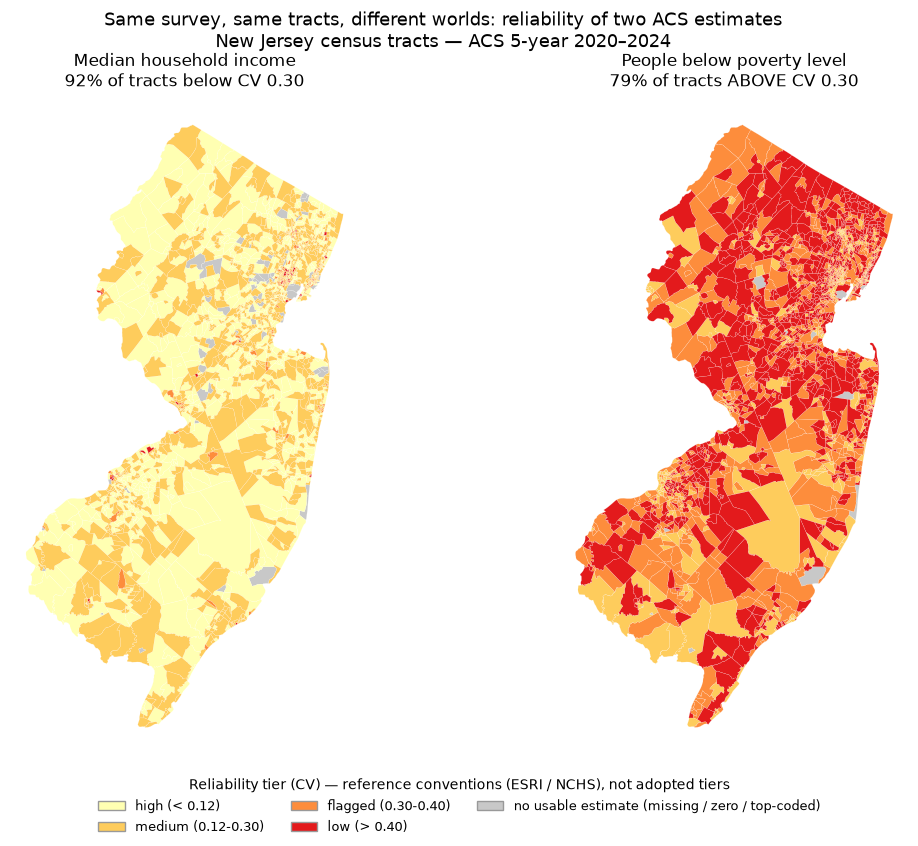

In [3]:
TIER_COLORS = {  # ColorBrewer YlOrRd 4-class (colorblind- and print-safe) + gray
    "high (< 0.12)": "#ffffb2",
    "medium (0.12-0.30)": "#fecc5c",
    "flagged (0.30-0.40)": "#fd8d3c",
    "low (> 0.40)": "#e31a1c",
}
GRAY = "#c8c8c8"

fig, axes = plt.subplots(1, 2, figsize=(13, 8.5))
panels = [
    ("income", "Median household income",
     f"{(gdf['cv_income'] < 0.30).mean():.0%} of tracts below CV 0.30"),
    ("poverty", "People below poverty level",
     f"{(gdf['cv_poverty'] > 0.30).mean():.0%} of tracts ABOVE CV 0.30"),
]
for ax, (var, title, subtitle) in zip(axes, panels):
    gdf[gdf[f"tier_{var}"].isna()].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.1)
    for tier, color in TIER_COLORS.items():
        sub = gdf[gdf[f"tier_{var}"] == tier]
        if len(sub):
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
    ax.set_axis_off()
    ax.set_title(f"{title}\n{subtitle}", fontsize=12)

handles = [Patch(facecolor=c, edgecolor="#999999", label=t) for t, c in TIER_COLORS.items()]
handles.append(Patch(facecolor=GRAY, edgecolor="#999999",
                     label="no usable estimate (missing / zero / top-coded)"))
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9.5, frameon=False,
           title="Reliability tier (CV) — reference conventions (ESRI / NCHS), not adopted tiers")
fig.suptitle(
    "Same survey, same tracts, different worlds: reliability of two ACS estimates\n"
    "New Jersey census tracts — ACS 5-year 2020–2024",
    fontsize=13,
)
fig.subplots_adjust(bottom=0.10, top=0.88)

out = REPO_ROOT / "data" / "processed" / "eda03_cv_choropleth_income_poverty.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Map saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

### Reading the maps

The income map is what most users would expect: broadly reliable, with scattered flagged tracts. The poverty map is the finding — **orange and red nearly everywhere**, with the notable exception of the urban cores (Newark, Paterson, Camden, Trenton, Atlantic City), which read as the *most* reliable places for poverty data.

That is the inversion Notebook 02's mechanism predicts: poverty CV falls where poverty counts are large, i.e., where poverty is common. Quantified below.

In [4]:
# The inversion: poverty-data reliability vs. poverty prevalence.
pov_rate = gdf["B17001_002E"] / gdf["B01003_001E"].where(gdf["B01003_001E"] > 0)
m = pov_rate.notna() & gdf["cv_poverty"].notna()
# Spearman via ranks (avoids a scipy dependency).
spearman = pov_rate[m].rank().corr(gdf.loc[m, "cv_poverty"].rank())

poorest_q = pov_rate > pov_rate.quantile(0.75)
least_poor_q = pov_rate < pov_rate.quantile(0.25)
med_poorest = gdf.loc[poorest_q, "cv_poverty"].median()
med_least = gdf.loc[least_poor_q, "cv_poverty"].median()

print(f"Spearman rank correlation, poverty rate vs. poverty CV: {spearman:+.2f}")
print(f"Median poverty CV in the poorest quartile of tracts:    {med_poorest:.3f}")
print(f"Median poverty CV in the least-poor quartile of tracts: {med_least:.3f}")

assert spearman < -0.4, "expected a strong negative rate-vs-CV relationship"
assert med_poorest < med_least, "poverty data should be MORE reliable where poverty is higher"

Spearman rank correlation, poverty rate vs. poverty CV: -0.58
Median poverty CV in the poorest quartile of tracts:    0.310
Median poverty CV in the least-poor quartile of tracts: 0.491


## 2. Findings

**What did we find?** Unreliability is not randomly scattered — it has geography, and for poverty that geography is *the inverse of poverty itself* (Spearman −0.58: median CV 0.31 in the poorest quartile of tracts vs. 0.49 in the least-poor quartile). Income tells the opposite, calmer story: 92% of tracts below CV 0.30, with reliability mildly rising with income. And the tier framework maps cleanly: a reader can see at a glance which parts of the state can support a tract-level poverty conversation and which cannot.

**Why does it matter to the Census Bureau?** Three things.
1. **The dashboard concept works.** Classed reliability tiers on a map communicate instantly in a way CV tables never will — this two-panel figure is, in miniature, deliverable #3.
2. **The equity implication cuts the unexpected way.** Poverty data is *most* reliable in high-poverty urban cores and *least* reliable in affluent and suburban tracts. Anyone tracking the suburbanization of poverty — a real policy question — is working with the least reliable numbers on the map, usually without knowing it.
3. **"No data" needs first-class treatment.** The gray class (missing / zero / top-coded) is information, and the final dashboard's tooltips must distinguish *why* an estimate is unusable — Notebook 01 showed those reasons can have opposite reliability meanings.

**What next?** Phase 1 Step 5's core is done: three notebooks, four mentor-ready charts. Remaining EDA items are **EDA #4** (DAS privacy noise — blocked on the Step 6 demonstration-file download) and **EDA #5** (ACS allocation rates — needs a small new API pull). Before the July 22 biweekly: assemble the one-slide status (candidate charts: Notebook 01's boxplot + this map pair) and bring the mentor questions, including the 131-tract population-MOE mystery from Notebook 02.